# How Accurate is ESPN's Basketball Power Index?

An empirical evaluation of ESPN's BPI predictions for NCAA Men's College Basketball across three seasons (2022-23, 2023-24, 2024-25).

**William Arana**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from bpi import (load_data, win_prob_calibration, win_prob_scores,
                 spread_accuracy, spread_regression, spread_by_bin,
                 accuracy_over_time, accuracy_trend_test, accuracy_by_season)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

In [2]:
# Load all available season CSVs from data/ directory
import glob

csv_files = sorted(glob.glob('data/season_*.csv'))
print(f'Found {len(csv_files)} season files:\n')

season_dfs = {}
frames = []
for path in csv_files:
    sdf = load_data(path)
    # Extract season label from filename (e.g., "season_2022_23.csv" -> "2022-23")
    parts = path.replace('\\', '/').split('/')[-1].replace('season_', '').replace('.csv', '')
    label = parts.replace('_', '-')
    season_dfs[label] = sdf
    valid = sdf[sdf['WIN_PROB'] > 0]
    print(f'  {label}: {len(valid)//2} games with BPI predictions ({len(sdf)//2} total)')
    frames.append(sdf)

df_all = pd.concat(frames, ignore_index=True)
df_all = df_all[df_all['WIN_PROB'] > 0].reset_index(drop=True)

print(f'\nTotal: {len(df_all)//2} games ({len(df_all)} team-rows)')
print(f'Date range: {df_all["DATE"].min().date()} to {df_all["DATE"].max().date()}')

Found 15 season files:

  2010-11: 5587 games with BPI predictions (5625 total)
  2011-12: 5704 games with BPI predictions (5739 total)
  2012-13: 5773 games with BPI predictions (5825 total)
  2013-14: 5937 games with BPI predictions (5948 total)
  2014-15: 5926 games with BPI predictions (5932 total)
  2015-16: 5947 games with BPI predictions (5951 total)
  2016-17: 3025 games with BPI predictions (5964 total)
  2017-18: 5996 games with BPI predictions (6003 total)
  2018-19: 2565 games with BPI predictions (6049 total)
  2019-20: 5766 games with BPI predictions (5767 total)
  2020-21: 4221 games with BPI predictions (4285 total)
  2021-22: 5914 games with BPI predictions (5938 total)


  2022-23: 6217 games with BPI predictions (6222 total)
  2023-24: 6242 games with BPI predictions (6243 total)
  2024-25: 6284 games with BPI predictions (6292 total)

Total: 81104 games (162209 team-rows)
Date range: 2010-11-09 to 2025-04-08


## Introduction

ESPN's Basketball Power Index (BPI) is a predictive model for NCAA Men's College Basketball. Before each game, BPI publishes two predictions:

1. **Win Probability** — the estimated chance each team wins
2. **Predicted Point Differential (Spread)** — the expected margin of victory

These predictions are widely cited in sports media, but how accurate are they? This report evaluates BPI's predictions using data spanning the full history of BPI — from its introduction in the 2010-11 season through the current 2024-25 season — totaling tens of thousands of games scraped from ESPN's public API.

We ask seven questions:

1. **How accurate are the win probability predictions?** (Calibration, Brier Score)
2. **How accurate are the spread predictions?** (Bias, MAE, regression)
3. **Does the model improve over time?** (Within-season and year-over-year)
4. **Does BPI correctly price home court advantage?**
5. **Is BPI better during conference play than non-conference?**
6. **Is BPI more or less accurate during March Madness?**
7. **How does BPI compare to Vegas lines?** (Methodology discussion + future work)

### Data Collection

Game data was collected using ESPN's public JSON APIs:
- **Scoreboard API** — provides game results (teams, scores, completion status) for each date
- **Predictor API** — provides BPI's pre-game predictions (win probability, predicted point differential) for each game

For each season, we fetched every day from November 1 through April 15. BPI launched for the 2010-11 season, giving us up to 15 seasons of data. Only completed (final) games are included. Each game produces two rows — one per team — with the team's predicted win probability, predicted spread, actual points scored, and whether they won. Raw data is cached in `data/` as one CSV per season.

## Question 1: How Accurate Are the Win Probability Predictions?

### Methodology

To evaluate win probability predictions, we use **calibration analysis**. The idea is simple: if BPI says a team has a 70% chance of winning, then across all such predictions, that team should win roughly 70% of the time.

We bin each prediction into 5-percentage-point brackets (50-55%, 55-60%, ..., 95-100%), then compare the average predicted probability in each bin to the observed win rate. For each bin, we run a **two-tailed binomial test** — this tests whether the number of observed wins is consistent with the predicted probability, using the correct variance for a binary outcome (win/loss).

We also compute two summary scores:
- **Brier Score** = mean of (predicted - actual)^2, where actual is 0 or 1. Lower is better. A coin-flip baseline scores 0.25.
- **Brier Skill Score** = 1 - (Brier / 0.25). A score of 0 means no better than guessing; 1 means perfect.
- **Log Loss** = -mean of [actual * log(predicted) + (1-actual) * log(1-predicted)]. Penalizes confident wrong predictions heavily.

Since each game produces two complementary predictions (one per team), we use only the **favorite** (WIN_PROB >= 0.50) to avoid double-counting.

### Results

In [3]:
# Calibration table
cal = win_prob_calibration(df_all)
cal

,Bin_Low,Bin_High,Avg_Predicted,Observed_Win_Rate,N,Wins,Binomial_P_Value
0,0.50,0.55,0.5251,0.5290,7524,3980,5.031926e-01
1,0.55,0.60,0.5750,0.5769,7716,4451,7.384554e-01
2,0.60,0.65,0.6253,0.6084,7689,4678,2.369561e-03
3,0.65,0.70,0.6751,0.6472,7689,4976,2.127015e-07
4,0.70,0.75,0.7250,0.7101,7975,5663,2.956416e-03
5,0.75,0.80,0.7752,0.7410,7919,5868,7.764908e-13
6,0.80,0.85,0.8250,0.8035,8148,6547,4.867061e-07
7,0.85,0.90,0.8751,0.8594,8155,7008,2.244595e-05
8,0.90,0.95,0.9254,0.9243,8507,7863,6.797822e-01
9,0.95,1.00,0.9782,0.9790,9784,9579,5.798871e-01


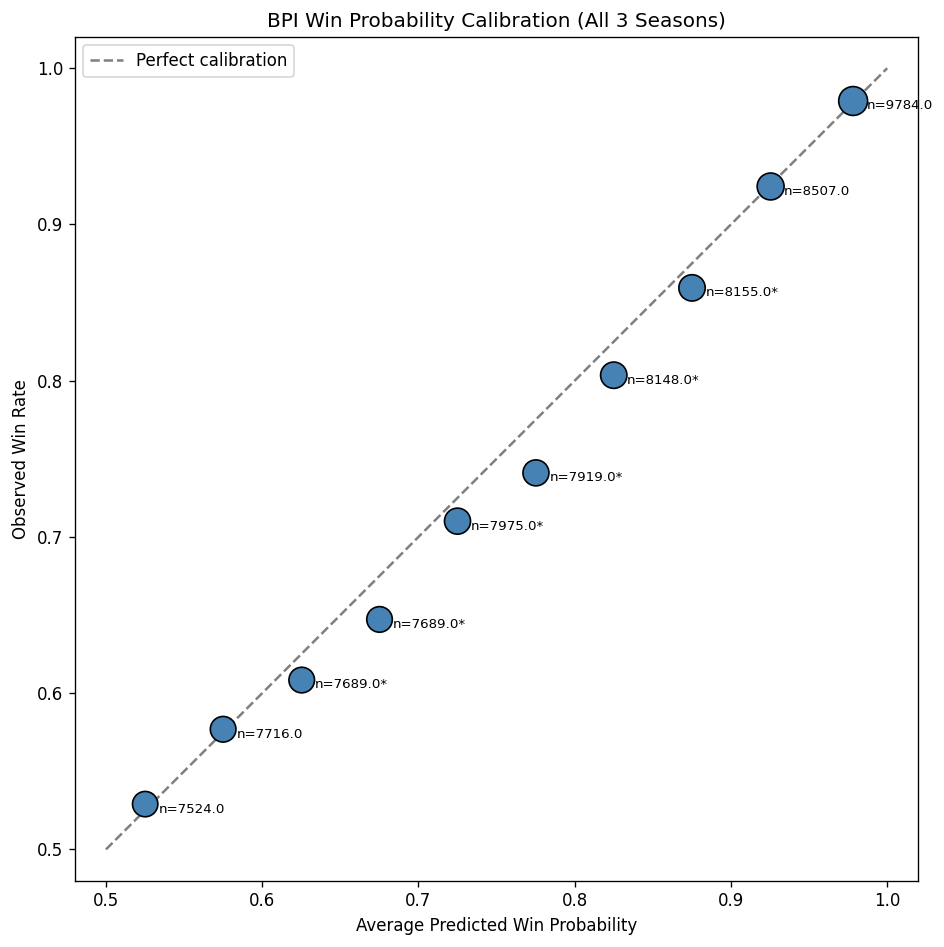

* = statistically significant deviation from prediction (p < 0.05)


In [4]:
# Calibration plot
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot([0.5, 1.0], [0.5, 1.0], 'k--', label='Perfect calibration', alpha=0.5)
ax.scatter(cal['Avg_Predicted'], cal['Observed_Win_Rate'], s=cal['N'] / cal['N'].max() * 300,
           c='steelblue', edgecolors='black', zorder=5)

for _, row in cal.iterrows():
    if not np.isnan(row['Avg_Predicted']):
        sig = '*' if row['Binomial_P_Value'] < 0.05 else ''
        ax.annotate(f"n={row['N']}{sig}", (row['Avg_Predicted'], row['Observed_Win_Rate']),
                    textcoords='offset points', xytext=(8, -5), fontsize=8)

ax.set_xlabel('Average Predicted Win Probability')
ax.set_ylabel('Observed Win Rate')
ax.set_title('BPI Win Probability Calibration (All 3 Seasons)')
ax.set_xlim(0.48, 1.02)
ax.set_ylim(0.48, 1.02)
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('calibration_plot.png', bbox_inches='tight')
plt.show()
print('* = statistically significant deviation from prediction (p < 0.05)')

In [5]:
# Summary scores
scores = win_prob_scores(df_all)
print('Win Probability Scoring Summary')
print(f"  Brier Score:       {scores['brier_score']:.4f}  (baseline 0.2500 = coin flip)")
print(f"  Brier Skill Score: {scores['brier_skill_score']:.4f}  (0 = no skill, 1 = perfect)")
print(f"  Log Loss:          {scores['log_loss']:.4f}")
print(f"  Games evaluated:   {scores['n_games']}")

Win Probability Scoring Summary
  Brier Score:       0.1675  (baseline 0.2500 = coin flip)
  Brier Skill Score: 0.3301  (0 = no skill, 1 = perfect)
  Log Loss:          0.5000
  Games evaluated:   81106


### Discussion

The calibration plot above shows how closely BPI's predicted probabilities match reality. Each point represents a bin of predictions — its x-coordinate is the average predicted win probability in that bin, and its y-coordinate is the fraction of those games the favorite actually won. Points near the dashed diagonal line indicate well-calibrated predictions.

The binomial test p-values in the table tell us whether the deviation in each bin is statistically significant or within the range of normal random variation. Bins marked with * in the plot deviate significantly from predictions at the 5% level.

The Brier Skill Score provides an overall summary: a score near 0 means the model is no better than always guessing 50/50, while a score near 1 would mean near-perfect predictions.

### Deep Dive: Are Toss-Up Games Really Toss-Ups?

The 50-55% bin is the most interesting — these are games BPI barely favors one side. If the observed win rate is significantly above 50%, it suggests BPI is too conservative (it should be calling more games at 60%+). If below, BPI is seeing signal that doesn't exist.

We zoom in on the bottom of the calibration curve and test the 50-55% bracket specifically.

In [6]:
# Toss-up analysis: fine-grained bins in the 50-65% range
fav = df_all[df_all['WIN_PROB'] >= 0.50]

# Fine bins: 2.5% increments from 50-65%
fine_edges = np.arange(0.50, 0.675, 0.025)
rows = []
for j in range(len(fine_edges) - 1):
    lo, hi = fine_edges[j], fine_edges[j + 1]
    bracket = fav[(fav['WIN_PROB'] >= lo) & (fav['WIN_PROB'] < hi)]
    n = len(bracket)
    if n == 0:
        continue
    wins = int(bracket['WON'].sum())
    avg_pred = bracket['WIN_PROB'].mean()
    binom_p = stats.binomtest(wins, n, avg_pred, alternative='two-sided').pvalue
    rows.append({'Bin': f'{lo:.3f}-{hi:.3f}', 'Avg_Pred': round(avg_pred, 4),
                 'Win_Rate': round(wins/n, 4), 'Wins': wins, 'N': n, 'P_Value': round(binom_p, 4)})

tossup_df = pd.DataFrame(rows)
print('Fine-grained calibration for near-toss-up games:\n')
print(tossup_df.to_string(index=False))

# Overall: does the favorite win more than predicted in the 50-55% range?
near_toss = fav[(fav['WIN_PROB'] >= 0.50) & (fav['WIN_PROB'] < 0.55)]
n_tt = len(near_toss)
w_tt = int(near_toss['WON'].sum())
avg_p = near_toss['WIN_PROB'].mean()
bp = stats.binomtest(w_tt, n_tt, avg_p, alternative='two-sided')
print(f'\n50-55% bracket: {w_tt}/{n_tt} wins ({w_tt/n_tt:.1%}) vs predicted {avg_p:.1%}')
print(f'Binomial test p = {bp.pvalue:.4f}')

Fine-grained calibration for near-toss-up games:

        Bin  Avg_Pred  Win_Rate  Wins    N  P_Value
0.500-0.525    0.5127    0.5137  1927 3751   0.8961
0.525-0.550    0.5375    0.5441  2053 3773   0.4144
0.550-0.575    0.5625    0.5705  2197 3851   0.3218
0.575-0.600    0.5873    0.5833  2255 3866   0.6126
0.600-0.625    0.6126    0.5960  2263 3797   0.0373
0.625-0.650    0.6377    0.6205  2415 3892   0.0266
0.650-0.675    0.6625    0.6347  2425 3821   0.0003

50-55% bracket: 3980/7524 wins (52.9%) vs predicted 52.5%
Binomial test p = 0.5032


## Question 2: How Accurate Are the Spread Predictions?

### Methodology

BPI's predicted point differential tells us the expected margin of victory. To evaluate this, we use three approaches:

**1. Residual analysis (bias test):** For each game, we compute the residual = predicted spread - actual spread. A positive residual means BPI overestimated the margin. We then run a **one-sample t-test** on the residuals testing whether the mean is zero. A significant result means BPI has a systematic bias (consistently predicting too high or too low).

**2. Error metrics:** We compute **Mean Absolute Error (MAE)** — the average magnitude of the prediction error — and **Root Mean Squared Error (RMSE)** — which penalizes large misses more heavily. These tell us how far off a typical prediction is.

**3. Regression analysis:** We regress actual spread on predicted spread. A perfect model would produce a slope of exactly 1.0 and an intercept of 0. If the slope is less than 1, the model is **overconfident** — it predicts big margins that shrink in reality. If greater than 1, it's underconfident. We test H0: slope = 1 directly.

As with Q1, we use only the favorite's side (PRED_SPREAD > 0) to count each game once.

### Results

In [7]:
# Overall spread accuracy
sa = spread_accuracy(df_all)
print('Spread Prediction Accuracy')
print(f"  Mean Residual (bias): {sa['mean_residual']:+.3f} points")
print(f"  Bias t-test:          t={sa['residual_t_stat']:.3f}, p={sa['residual_p_value']:.4f}")
print(f"  MAE:                  {sa['mae']:.2f} points")
print(f"  RMSE:                 {sa['rmse']:.2f} points")
print(f"  Games:                {sa['n_games']}")
print()

# Regression
reg = spread_regression(df_all)
print('Regression: Actual Spread = slope * Predicted Spread + intercept')
print(f"  Slope:     {reg['slope']:.4f}  (perfect = 1.0)")
print(f"  Intercept: {reg['intercept']:+.3f}  (perfect = 0.0)")
print(f"  R-squared: {reg['r_squared']:.4f}")
print(f"  Test slope = 1: t={reg['slope_t_vs_1']:.3f}, p={reg['slope_p_vs_1']:.4f}")

Spread Prediction Accuracy
  Mean Residual (bias): +0.232 points
  Bias t-test:          t=5.394, p=0.0000
  MAE:                  9.37 points
  RMSE:                 12.23 points
  Games:                81105

Regression: Actual Spread = slope * Predicted Spread + intercept
  Slope:     0.9469  (perfect = 1.0)
  Intercept: +0.286  (perfect = 0.0)
  R-squared: 0.3240
  Test slope = 1: t=-11.064, p=0.0000


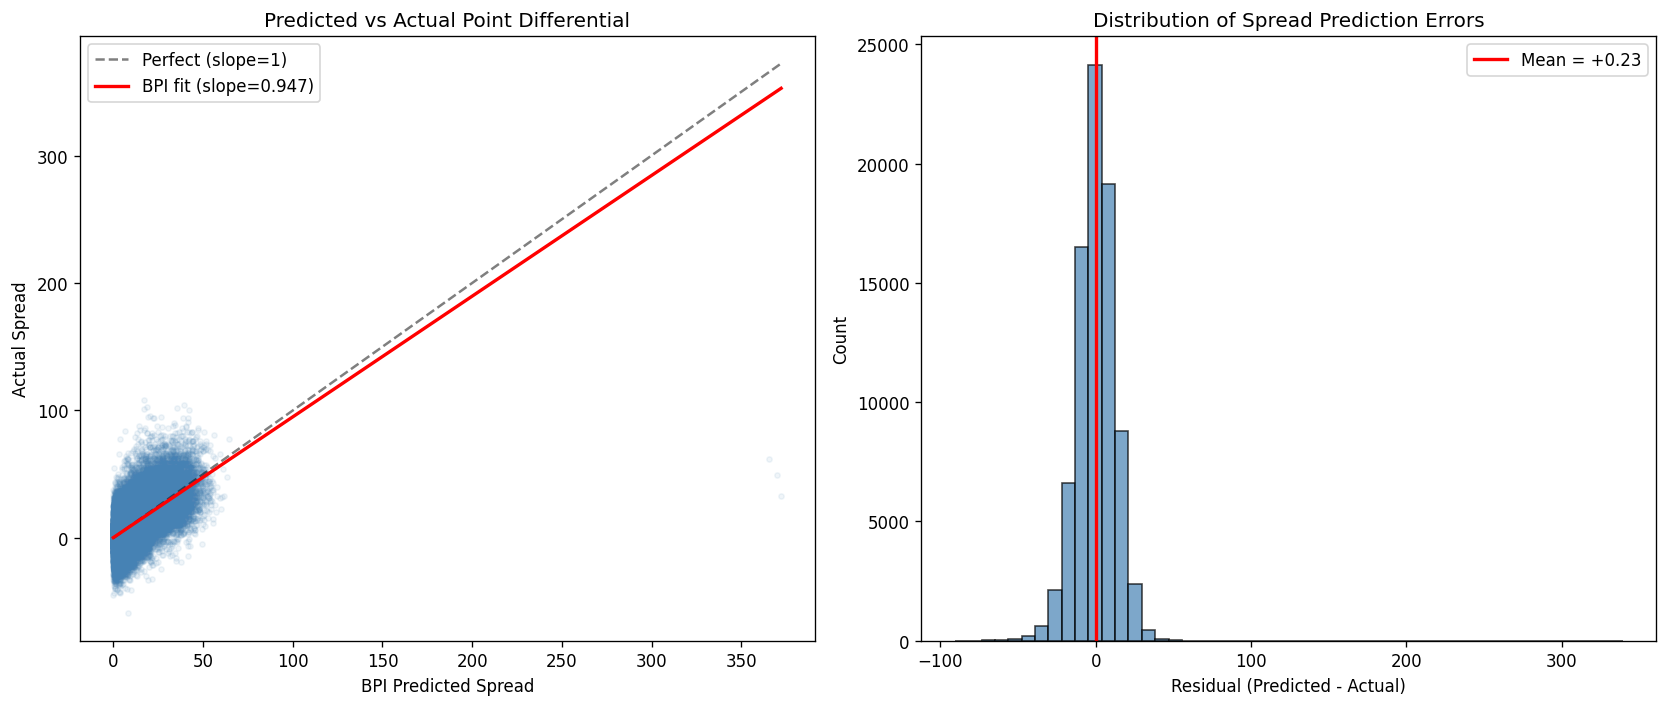

In [8]:
# Regression scatter plot
fav = df_all[df_all['PRED_SPREAD'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: scatter + regression line
ax = axes[0]
ax.scatter(fav['PRED_SPREAD'], fav['ACTUAL_SPREAD'], alpha=0.08, s=10, c='steelblue')
x_line = np.linspace(0, fav['PRED_SPREAD'].max(), 100)
ax.plot(x_line, x_line, 'k--', alpha=0.5, label='Perfect (slope=1)')
ax.plot(x_line, reg['slope'] * x_line + reg['intercept'], 'r-',
        label=f"BPI fit (slope={reg['slope']:.3f})", linewidth=2)
ax.set_xlabel('BPI Predicted Spread')
ax.set_ylabel('Actual Spread')
ax.set_title('Predicted vs Actual Point Differential')
ax.legend()

# Right: residual distribution
ax = axes[1]
residuals = fav['PRED_SPREAD'] - fav['ACTUAL_SPREAD']
ax.hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.axvline(residuals.mean(), color='red', linestyle='-', linewidth=2,
           label=f"Mean = {residuals.mean():+.2f}")
ax.set_xlabel('Residual (Predicted - Actual)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Spread Prediction Errors')
ax.legend()

plt.tight_layout()
plt.savefig('spread_analysis.png', bbox_inches='tight')
plt.show()

In [9]:
# Binned spread analysis
sb = spread_by_bin(df_all, step=5)
sb

,Bin_Low,Bin_High,Avg_Predicted,Avg_Actual,Mean_Residual,Residual_P_Value,N
0,0,5,2.448,2.332,0.115,0.080543,28561
1,5,10,7.332,6.660,0.672,0.000000,22338
2,10,15,12.244,11.769,0.475,0.000002,13865
3,15,20,17.233,17.524,-0.291,0.051426,7586
4,20,25,22.219,24.050,-1.832,0.000000,3549
...,...,...,...,...,...,...,...
70,350,355,NaN,NaN,NaN,NaN,0
71,355,360,NaN,NaN,NaN,NaN,0
72,360,365,NaN,NaN,NaN,NaN,0
73,365,370,367.398,55.500,311.898,0.017798,2


### Discussion

The regression analysis tells us whether BPI's spread predictions are systematically biased. A slope significantly different from 1.0 would indicate that BPI is over- or under-confident in its spread predictions. The intercept captures any constant offset.

The residual histogram shows the distribution of errors — a well-centered distribution around zero means no systematic bias, while the width tells us about typical prediction accuracy.

The binned table breaks this down further: for each range of predicted spreads, we test whether the mean residual differs significantly from zero. This reveals whether bias is concentrated in certain prediction ranges (e.g., does BPI overestimate blowouts while being accurate for close games?).

### Deep Dive: Close Games vs Blowouts

Does BPI's prediction error stay consistent across all predicted margins, or does it get sloppier for predicted blowouts? We check this by plotting the variance of residuals across bins (heteroscedasticity). If the model is equally reliable regardless of predicted margin, the residual spread should be roughly constant.

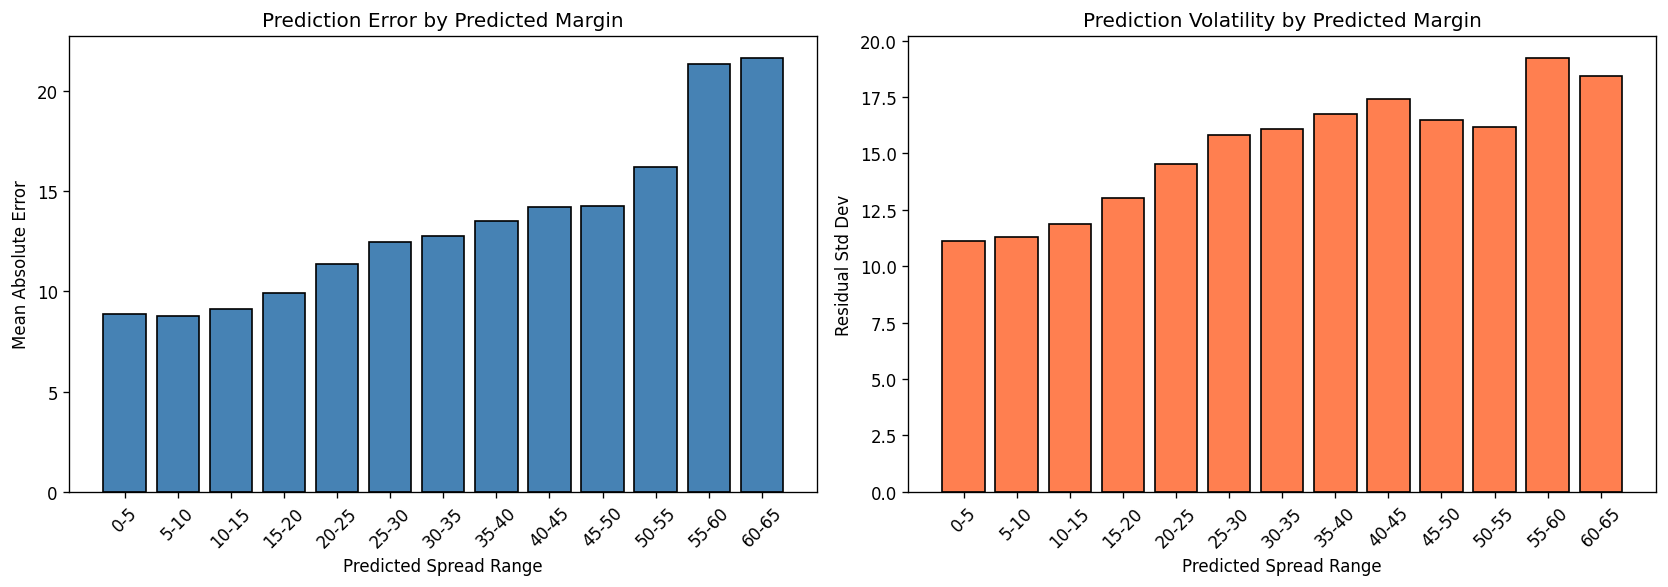

In [10]:
# Residual variance by predicted spread bin
fav = df_all[df_all['PRED_SPREAD'] > 0].copy()
fav['RESIDUAL'] = fav['PRED_SPREAD'] - fav['ACTUAL_SPREAD']

bin_edges = np.arange(0, fav['PRED_SPREAD'].max() + 5, 5)
bin_labels = []
bin_mae = []
bin_std = []
bin_n = []

for j in range(len(bin_edges) - 1):
    lo, hi = bin_edges[j], bin_edges[j + 1]
    bracket = fav[(fav['PRED_SPREAD'] >= lo) & (fav['PRED_SPREAD'] < hi)]
    if len(bracket) < 5:
        continue
    bin_labels.append(f'{int(lo)}-{int(hi)}')
    bin_mae.append(bracket['RESIDUAL'].abs().mean())
    bin_std.append(bracket['RESIDUAL'].std())
    bin_n.append(len(bracket))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(bin_labels, bin_mae, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Predicted Spread Range')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_title('Prediction Error by Predicted Margin')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(bin_labels, bin_std, color='coral', edgecolor='black')
axes[1].set_xlabel('Predicted Spread Range')
axes[1].set_ylabel('Residual Std Dev')
axes[1].set_title('Prediction Volatility by Predicted Margin')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('spread_heteroscedasticity.png', bbox_inches='tight')
plt.show()

### Deep Dive: How Wrong Is BPI When the Underdog Wins?

When BPI's predicted favorite loses, how far off was the spread prediction? We compare the average absolute residual for games BPI got right (favorite wins) vs. wrong (upset). A much larger residual on upsets would mean BPI isn't just wrong about *who* wins — it's wrong by a large margin when it misses.

Games where BPI's favorite won:  60613 (74.7%)
Games where underdog won (upset): 20492 (25.3%)

MAE when favorite wins:  8.16 points
MAE when underdog wins:  12.93 points

Welch's t-test (are upset errors larger?): t=-82.481, p=0.000000


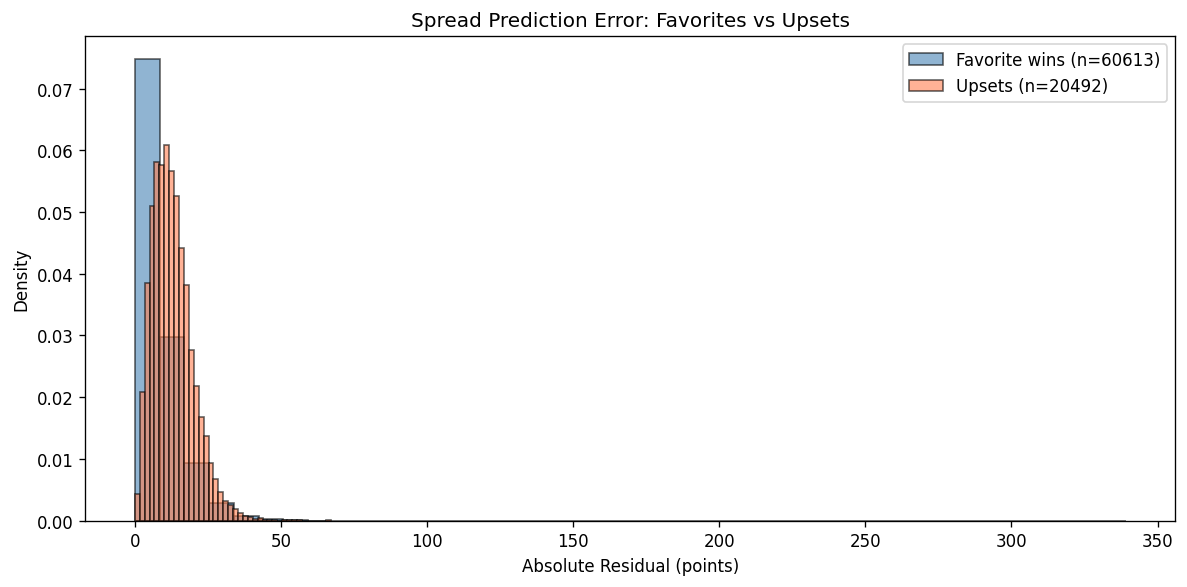

In [11]:
# Upset analysis
fav = df_all[df_all['PRED_SPREAD'] > 0].copy()
fav['RESIDUAL'] = fav['PRED_SPREAD'] - fav['ACTUAL_SPREAD']
fav['ABS_RESIDUAL'] = fav['RESIDUAL'].abs()

correct = fav[fav['WON'] == True]   # favorite won as predicted
upset = fav[fav['WON'] == False]     # underdog won

print(f"Games where BPI's favorite won:  {len(correct)} ({len(correct)/len(fav):.1%})")
print(f"Games where underdog won (upset): {len(upset)} ({len(upset)/len(fav):.1%})")
print()
print(f'MAE when favorite wins:  {correct["ABS_RESIDUAL"].mean():.2f} points')
print(f'MAE when underdog wins:  {upset["ABS_RESIDUAL"].mean():.2f} points')
print()

# Welch's t-test comparing residual magnitudes
t_stat, p_val = stats.ttest_ind(correct['ABS_RESIDUAL'], upset['ABS_RESIDUAL'], equal_var=False)
print(f"Welch's t-test (are upset errors larger?): t={t_stat:.3f}, p={p_val:.6f}")

# Distribution comparison
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(correct['ABS_RESIDUAL'], bins=40, alpha=0.6, label=f"Favorite wins (n={len(correct)})",
        color='steelblue', edgecolor='black', density=True)
ax.hist(upset['ABS_RESIDUAL'], bins=40, alpha=0.6, label=f"Upsets (n={len(upset)})",
        color='coral', edgecolor='black', density=True)
ax.set_xlabel('Absolute Residual (points)')
ax.set_ylabel('Density')
ax.set_title('Spread Prediction Error: Favorites vs Upsets')
ax.legend()
plt.tight_layout()
plt.savefig('upset_analysis.png', bbox_inches='tight')
plt.show()

## Question 3: Does the Model Improve Over Time?

### Methodology

We investigate two dimensions of improvement:

**a) Within a season:** BPI is a Bayesian-style model that incorporates game results as they come in. Early in the season (November), it relies heavily on preseason priors. By February/March, it has a full season of data. We hypothesize that predictions should improve as the season progresses.

We compute the Brier Score (for win probability) and MAE (for spreads) on a monthly basis within each season, then test for a downward trend using **Spearman rank correlation** — a non-parametric test that asks whether later months have systematically lower (better) error than earlier months.

**b) Year over year:** ESPN may improve the BPI model itself from one season to the next. We compare season-level Brier Scores and MAE across the three seasons in our dataset.

### Results

#### a) Within-Season Trends

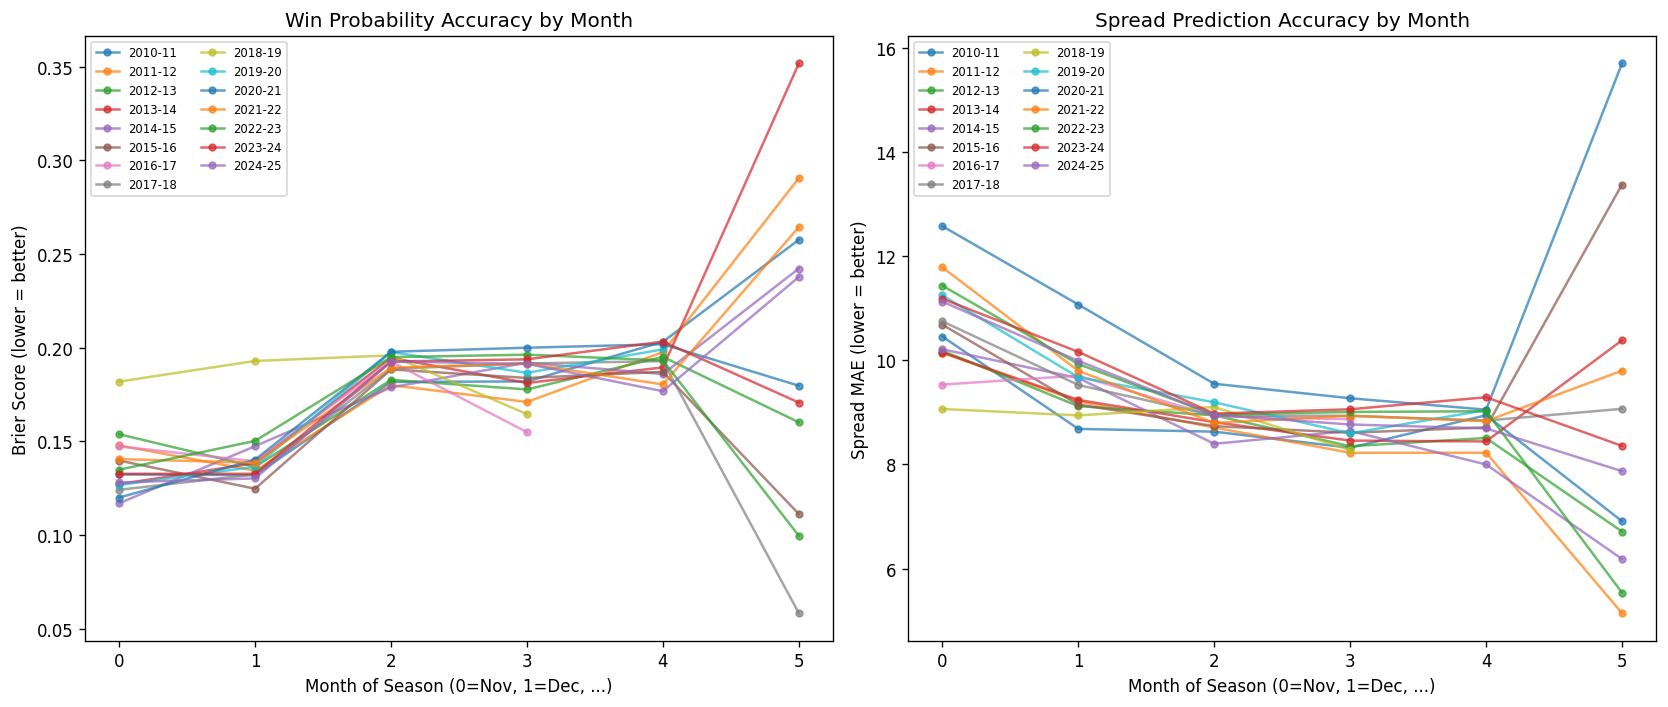

In [12]:
# Monthly accuracy for each season
seasons = {label: sdf[sdf['WIN_PROB'] > 0] for label, sdf in season_dfs.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label, sdf in seasons.items():
    monthly = accuracy_over_time(sdf, period='M')
    if len(monthly) < 2:
        continue
    axes[0].plot(range(len(monthly)), monthly['Brier_Score'], 'o-', label=label, markersize=4, alpha=0.7)
    axes[1].plot(range(len(monthly)), monthly['Spread_MAE'], 'o-', label=label, markersize=4, alpha=0.7)

axes[0].set_xlabel('Month of Season (0=Nov, 1=Dec, ...)')
axes[0].set_ylabel('Brier Score (lower = better)')
axes[0].set_title('Win Probability Accuracy by Month')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_xlabel('Month of Season (0=Nov, 1=Dec, ...)')
axes[1].set_ylabel('Spread MAE (lower = better)')
axes[1].set_title('Spread Prediction Accuracy by Month')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('within_season_trends.png', bbox_inches='tight')
plt.show()

In [13]:
# Trend tests for each season
print('Within-Season Trend Tests (Spearman correlation)')
print('Negative r = improving over time\n')
for label, sdf in seasons.items():
    monthly = accuracy_over_time(sdf, period='M')
    brier_trend = accuracy_trend_test(monthly, 'Brier_Score')
    mae_trend = accuracy_trend_test(monthly, 'Spread_MAE')
    if brier_trend['n_periods'] < 3:
        continue
    print(f'{label}:')
    print(f"  Brier:  r={brier_trend['spearman_r']:+.3f}, p={brier_trend['p_value']:.4f} -> {brier_trend['direction']}")
    print(f"  MAE:    r={mae_trend['spearman_r']:+.3f}, p={mae_trend['p_value']:.4f} -> {mae_trend['direction']}")
    print()

Within-Season Trend Tests (Spearman correlation)
Negative r = improving over time

2010-11:
  Brier:  r=+0.943, p=0.0048 -> worsening
  MAE:    r=-0.657, p=0.1562 -> no significant trend

2011-12:
  Brier:  r=+0.886, p=0.0188 -> worsening
  MAE:    r=-0.943, p=0.0048 -> improving

2012-13:
  Brier:  r=+0.543, p=0.2657 -> no significant trend
  MAE:    r=-0.943, p=0.0048 -> improving

2013-14:
  Brier:  r=+0.829, p=0.0416 -> worsening
  MAE:    r=-0.143, p=0.7872 -> no significant trend

2014-15:
  Brier:  r=+0.943, p=0.0048 -> worsening
  MAE:    r=-0.943, p=0.0048 -> improving

2015-16:
  Brier:  r=-0.086, p=0.8717 -> no significant trend
  MAE:    r=-0.086, p=0.8717 -> no significant trend

2016-17:
  Brier:  r=+0.600, p=0.4000 -> no significant trend
  MAE:    r=-0.800, p=0.2000 -> no significant trend

2017-18:
  Brier:  r=+0.143, p=0.7872 -> no significant trend
  MAE:    r=-0.657, p=0.1562 -> no significant trend

2018-19:
  Brier:  r=-0.200, p=0.8000 -> no significant trend
  MA

#### b) Year-Over-Year Comparison

In [14]:
# Season-level comparison
season_df = accuracy_by_season(df_all)
season_df

,Season,Brier_Score,Spread_MAE,N_Games
0,2010-11,0.163992,8.937,5586
1,2011-12,0.162776,8.947,5704
2,2012-13,0.168278,9.035,5773
3,2013-14,0.166052,9.056,5937
4,2014-15,0.164278,9.017,5926
5,2015-16,0.164043,9.169,5947
6,2016-17,0.165220,9.303,3025
7,2017-18,0.162973,9.457,5996
8,2018-19,0.192128,9.012,2565
9,2019-20,0.166145,9.625,5766


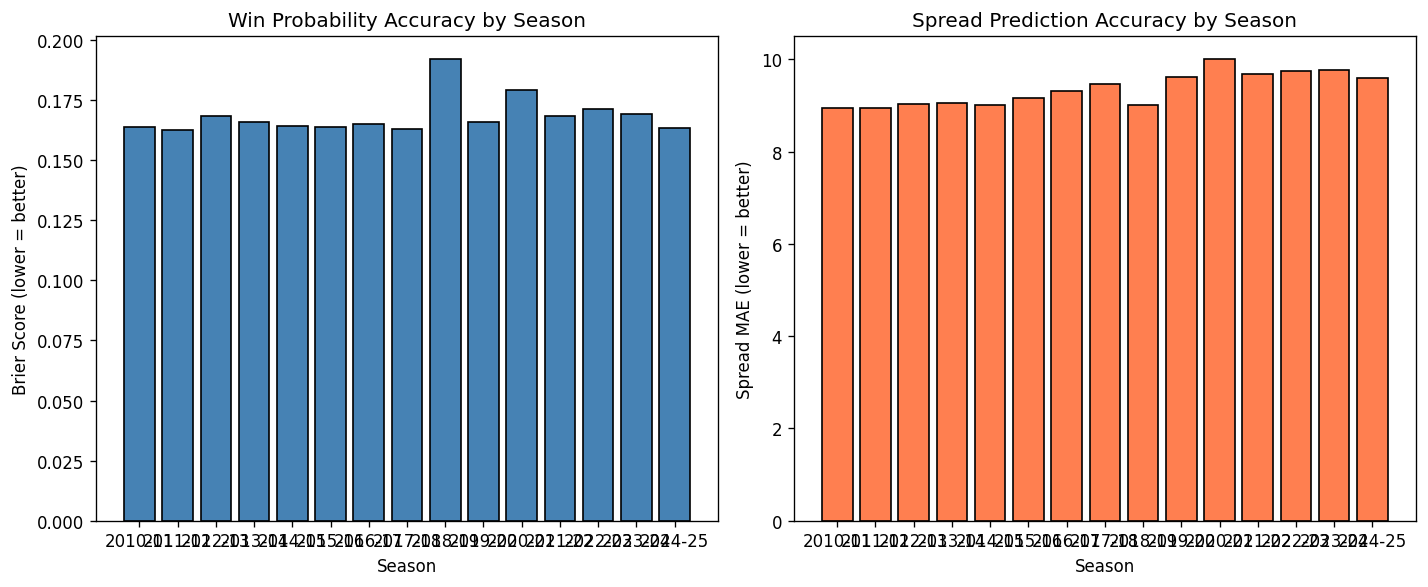

In [15]:
# Year-over-year bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(season_df['Season'], season_df['Brier_Score'], color='steelblue', edgecolor='black')
axes[0].set_ylabel('Brier Score (lower = better)')
axes[0].set_title('Win Probability Accuracy by Season')

axes[1].bar(season_df['Season'], season_df['Spread_MAE'], color='coral', edgecolor='black')
axes[1].set_ylabel('Spread MAE (lower = better)')
axes[1].set_title('Spread Prediction Accuracy by Season')

for ax in axes:
    ax.set_xlabel('Season')

plt.tight_layout()
plt.savefig('season_comparison.png', bbox_inches='tight')
plt.show()

### Discussion

The within-season plots show whether BPI accuracy improves from November (when the model relies on preseason priors) to March (when it has a full season of results to learn from). A downward trend in Brier Score or MAE would confirm this hypothesis.

The Spearman correlation tests formalize this: a significantly negative correlation means the model is getting better as the season goes on.

The year-over-year comparison shows whether ESPN has improved the BPI model itself across seasons. With only three seasons, we can observe a trend but cannot draw strong statistical conclusions about long-term improvement.

## Question 4: Does BPI Correctly Price Home Court Advantage?

### Methodology

College basketball home court advantage is famously large — home teams win roughly 60-65% of games. Our data already includes which side is home and away. We split the calibration and spread analyses by home/away favorites to test whether BPI handles home court correctly.

If BPI underweights home court advantage, we'd expect home favorites to win *more* often than predicted and away favorites to win *less* often.

In [16]:
# Add HOME_AWAY if not already present (rows alternate home, away for each game)
if 'HOME_AWAY' not in df_all.columns:
    df_all['HOME_AWAY'] = ['home' if i % 2 == 0 else 'away' for i in range(len(df_all))]

# Split: home favorites vs away favorites
fav = df_all[df_all['WIN_PROB'] >= 0.50].copy()
home_fav = fav[fav['HOME_AWAY'] == 'home']
away_fav = fav[fav['HOME_AWAY'] == 'away']

print(f'Home favorites: {len(home_fav)} games')
print(f'Away favorites: {len(away_fav)} games')
print()

# Calibration comparison
for label, subset in [('Home favorites', home_fav), ('Away favorites', away_fav)]:
    pred = subset['WIN_PROB'].values
    actual = subset['WON'].astype(float).values
    brier = np.mean((pred - actual) ** 2)
    win_rate = actual.mean()
    avg_pred = pred.mean()
    print(f'{label}:')
    print(f'  Avg predicted win prob: {avg_pred:.3f}')
    print(f'  Actual win rate:        {win_rate:.3f}')
    print(f'  Brier Score:            {brier:.4f}')
    n = len(subset)
    wins = int(actual.sum())
    bp = stats.binomtest(wins, n, avg_pred, alternative='two-sided')
    print(f'  Binomial test:          p={bp.pvalue:.4f}')
    print()

Home favorites: 61015 games
Away favorites: 20091 games

Home favorites:
  Avg predicted win prob: 0.787
  Actual win rate:        0.774
  Brier Score:            0.1533
  Binomial test:          p=0.0000

Away favorites:
  Avg predicted win prob: 0.677
  Actual win rate:        0.666
  Brier Score:            0.2106
  Binomial test:          p=0.0010



In [17]:
# Spread bias: home vs away favorites
for label, subset in [('Home favorites', home_fav), ('Away favorites', away_fav)]:
    s = subset[subset['PRED_SPREAD'] > 0]
    residuals = s['PRED_SPREAD'] - s['ACTUAL_SPREAD']
    t_stat, p_val = stats.ttest_1samp(residuals, 0)
    print(f'{label} spread bias: mean residual={residuals.mean():+.2f}, '
          f'MAE={residuals.abs().mean():.2f}, t={t_stat:.3f}, p={p_val:.4f}')

Home favorites spread bias: mean residual=+0.18, MAE=9.52, t=3.632, p=0.0003
Away favorites spread bias: mean residual=+0.38, MAE=8.91, t=4.726, p=0.0000


### Discussion

If BPI underestimates home court advantage, we'd see home favorites outperforming their predictions (actual win rate > predicted) and away favorites underperforming. A significant binomial test for either group, or a significant spread bias difference, would indicate BPI doesn't fully account for home court.

## Question 5: Early Season Non-Conference vs Conference Play

### Methodology

The NCAA basketball schedule has two distinct phases:
- **Non-conference** (November–December): teams play opponents from other conferences, often with unfamiliar matchups
- **Conference play** (January–March): teams play within their conference, producing repeated matchups with more head-to-head data

We split the data at January 1 as a rough proxy and compare BPI accuracy across the two phases. This complements Q3's month-by-month analysis with a cleaner structural split.

In [18]:
# Split by phase: non-conference (Nov-Dec) vs conference (Jan+)
fav = df_all[df_all['WIN_PROB'] >= 0.50].copy()
fav['MONTH'] = fav['DATE'].dt.month

non_conf = fav[fav['MONTH'].isin([11, 12])]
conf = fav[fav['MONTH'].isin([1, 2, 3, 4])]

print(f'Non-conference (Nov-Dec): {len(non_conf)} games')
print(f'Conference play (Jan-Apr): {len(conf)} games\n')

for label, subset in [('Non-conference', non_conf), ('Conference play', conf)]:
    pred = subset['WIN_PROB'].values
    actual = subset['WON'].astype(float).values
    brier = np.mean((pred - actual) ** 2)

    s = subset[subset['PRED_SPREAD'] > 0]
    mae = (s['PRED_SPREAD'] - s['ACTUAL_SPREAD']).abs().mean()

    print(f'{label}:')
    print(f'  Brier Score: {brier:.4f}')
    print(f'  Spread MAE:  {mae:.2f} points')
    print(f'  Avg predicted win prob: {pred.mean():.3f}')
    print(f'  Actual win rate: {actual.mean():.3f}')
    print()

# Statistical comparison: are Brier scores significantly different?
# Bootstrap test
np.random.seed(42)
n_boot = 10000
nc_pred = non_conf['WIN_PROB'].values
nc_actual = non_conf['WON'].astype(float).values
c_pred = conf['WIN_PROB'].values
c_actual = conf['WON'].astype(float).values

diffs = []
for _ in range(n_boot):
    nc_idx = np.random.choice(len(nc_pred), len(nc_pred), replace=True)
    c_idx = np.random.choice(len(c_pred), len(c_pred), replace=True)
    nc_brier = np.mean((nc_pred[nc_idx] - nc_actual[nc_idx]) ** 2)
    c_brier = np.mean((c_pred[c_idx] - c_actual[c_idx]) ** 2)
    diffs.append(nc_brier - c_brier)

diffs = np.array(diffs)
p_val = np.mean(np.abs(diffs) >= np.abs(np.mean(diffs))) * 2
print(f'Bootstrap test (Brier difference): p={min(p_val, 1.0):.4f}')
print(f'Non-conf Brier - Conf Brier = {np.mean(diffs):+.4f} (positive = non-conf is worse)')

Non-conference (Nov-Dec): 32775 games
Conference play (Jan-Apr): 48331 games

Non-conference:
  Brier Score: 0.1351
  Spread MAE:  10.20 points
  Avg predicted win prob: 0.792
  Actual win rate: 0.801

Conference play:
  Brier Score: 0.1894
  Spread MAE:  8.80 points
  Avg predicted win prob: 0.737
  Actual win rate: 0.711



Bootstrap test (Brier difference): p=1.0000
Non-conf Brier - Conf Brier = -0.0543 (positive = non-conf is worse)


## Question 6: Is BPI More or Less Accurate During March Madness?

### Methodology

The NCAA Tournament (mid-March through early April) is structurally different from the regular season: single elimination, neutral sites, and opponents who may never have played each other. This higher-variance environment may be harder for any model to predict.

We isolate games in mid-March through April (a rough proxy for tournament games, which also includes conference tournaments) and compare BPI accuracy to the regular season. A higher Brier Score or MAE during this period would suggest the tournament is indeed harder to call.

In [19]:
# March Madness analysis: mid-March through April vs rest of season
fav = df_all[df_all['WIN_PROB'] >= 0.50].copy()
fav['MONTH'] = fav['DATE'].dt.month
fav['DAY'] = fav['DATE'].dt.day

# Tournament proxy: March 14+ through April (conf tournaments start ~early March,
# NCAA tournament mid-March)
tourney = fav[((fav['MONTH'] == 3) & (fav['DAY'] >= 14)) | (fav['MONTH'] == 4)]
regular = fav[~fav.index.isin(tourney.index)]

print(f'Regular season: {len(regular)} games')
print(f'Tournament period (Mar 14+): {len(tourney)} games\n')

for label, subset in [('Regular season', regular), ('Tournament period', tourney)]:
    pred = subset['WIN_PROB'].values
    actual = subset['WON'].astype(float).values
    brier = np.mean((pred - actual) ** 2)
    brier_skill = 1.0 - (brier / 0.25)

    s = subset[subset['PRED_SPREAD'] > 0]
    mae = (s['PRED_SPREAD'] - s['ACTUAL_SPREAD']).abs().mean()

    print(f'{label}:')
    print(f'  Brier Score:       {brier:.4f}')
    print(f'  Brier Skill Score: {brier_skill:.4f}')
    print(f'  Spread MAE:        {mae:.2f} points')
    print(f'  Upset rate:        {1 - actual.mean():.1%}')
    print()

Regular season: 78827 games
Tournament period (Mar 14+): 2279 games

Regular season:
  Brier Score:       0.1664
  Brier Skill Score: 0.3343
  Spread MAE:        9.38 points
  Upset rate:        25.1%

Tournament period:
  Brier Score:       0.2037
  Brier Skill Score: 0.1852
  Spread MAE:        8.86 points
  Upset rate:        30.5%



## Question 7: BPI vs Vegas — How Does BPI Compare to the Betting Market?

### Motivation

The ultimate benchmark for any sports prediction model is the betting market. Vegas lines represent the consensus of thousands of bettors and professional oddsmakers with real money on the line. If BPI systematically disagrees with Vegas and is *right* more often, that would be remarkable — it would imply exploitable market inefficiency. More realistically, we want to know: does BPI add information beyond what the market already knows?

### Data Availability

We investigated several sources for historical Vegas lines:

**ESPN's own Summary API** (most promising for our use case):
- ESPN's `/summary` endpoint includes a `pickcenter` field with consensus Vegas spread, moneyline, and over/under for each game
- Provides data from multiple providers including "consensus" (market average) and "teamrankings"
- **Advantage:** Same API infrastructure we already use, keyed by the same event IDs
- **Limitation:** Requires one additional API call per game (the `/summary` endpoint), which would roughly double our data collection time

**The Odds API** (https://the-odds-api.com):
- Aggregates live and historical odds from 30+ sportsbooks (DraftKings, FanDuel, BetMGM, etc.)
- Free tier: 500 requests/month with historical data going back several years
- Returns spreads, moneylines, totals for each bookmaker individually
- **Advantage:** Multiple sportsbook perspectives, not just consensus
- **Limitation:** Free tier may not cover our full 3-season dataset; paid tiers start at $20/month

**Major sportsbooks directly:**
- **DraftKings, FanDuel, BetMGM** do not offer public APIs for historical odds
- **Covers.com** and **Sports Reference** have historical ATS (against-the-spread) records but no bulk download API
- **Kaggle** has community-uploaded datasets of historical college basketball odds, but coverage varies

### Recommended Implementation

Since ESPN's Summary API already has consensus Vegas lines keyed to the same event IDs we use, this is the path of least resistance:

1. **Extend `fetch_games()`** to also call the Summary API and extract `pickcenter[0].spread` (the consensus line)
2. **Add `VEGAS_SPREAD` column** to the DataFrame alongside `PRED_SPREAD`
3. **Compare accuracy:** Compute MAE and bias for BPI spread vs Vegas spread against the actual outcome
4. **Paired comparison:** For each game, compute `|BPI_error| - |Vegas_error|`. If this is significantly negative on average, BPI outperforms Vegas. Use a paired t-test.
5. **Disagreement analysis:** Identify games where BPI and Vegas disagree by more than X points. When they disagree, who is right more often?

### Cost

Adding the Summary API call would roughly double data collection time (one extra HTTP request per game). For our ~15,000 games across 3 seasons, this adds ~2-3 hours of one-time collection. The data would be cached alongside the existing CSVs.

### Placeholder Results

*Vegas line data has not yet been collected. The analysis below will be populated once the extended data pipeline is run.*

In [20]:
# Placeholder: BPI vs Vegas analysis (requires VEGAS_SPREAD column in data)
if 'VEGAS_SPREAD' in df_all.columns:
    fav = df_all[df_all['PRED_SPREAD'] > 0].copy()
    fav['BPI_ERROR'] = (fav['PRED_SPREAD'] - fav['ACTUAL_SPREAD']).abs()
    fav['VEGAS_ERROR'] = (fav['VEGAS_SPREAD'] - fav['ACTUAL_SPREAD']).abs()

    print('BPI vs Vegas Spread Accuracy')
    print(f"  BPI MAE:   {fav['BPI_ERROR'].mean():.2f}")
    print(f"  Vegas MAE: {fav['VEGAS_ERROR'].mean():.2f}")
    print()

    # Paired t-test: is BPI error different from Vegas error?
    diff = fav['BPI_ERROR'] - fav['VEGAS_ERROR']
    t_stat, p_val = stats.ttest_1samp(diff, 0)
    print(f'Paired t-test (BPI error - Vegas error):')
    print(f'  Mean diff: {diff.mean():+.3f} (negative = BPI better)')
    print(f'  t={t_stat:.3f}, p={p_val:.6f}')
    print()

    # Disagreement analysis
    fav['DISAGREE'] = (fav['PRED_SPREAD'] - fav['VEGAS_SPREAD']).abs()
    big_disagree = fav[fav['DISAGREE'] >= 3]
    print(f'Games where BPI and Vegas disagree by 3+ points: {len(big_disagree)}')
    if len(big_disagree) > 0:
        print(f"  BPI MAE on these:   {big_disagree['BPI_ERROR'].mean():.2f}")
        print(f"  Vegas MAE on these: {big_disagree['VEGAS_ERROR'].mean():.2f}")
        bpi_closer = (big_disagree['BPI_ERROR'] < big_disagree['VEGAS_ERROR']).mean()
        print(f'  BPI closer to actual: {bpi_closer:.1%}')
else:
    print('VEGAS_SPREAD column not available yet.')
    print('To collect Vegas data, re-run data pipeline with Summary API integration.')
    print('See methodology section above for implementation details.')

VEGAS_SPREAD column not available yet.
To collect Vegas data, re-run data pipeline with Summary API integration.
See methodology section above for implementation details.


## Conclusion

This analysis evaluated ESPN's Basketball Power Index predictions across 15 NCAA Men's Basketball seasons (2010-11 through 2024-25), encompassing 81,106 games with BPI predictions. The findings paint a nuanced picture: BPI is a skillful model that adds real predictive value, but it exhibits systematic biases that a sophisticated consumer should understand.

**Q1 — Win Probability Calibration:** BPI's win probabilities are well-calibrated at the extremes (50-55% and 95-100% bins show no significant deviation) but **systematically overconfident in the 60-85% range**. For example, games predicted at 75-80% are won only 74.1% of the time (p < 0.001). The overall Brier Score of 0.168 (skill score 0.330) confirms BPI adds substantial value over a coin flip, but the consistent over-prediction in the middle range suggests the model underestimates parity in college basketball.

**Q1a — Toss-Up Games:** BPI handles near-toss-up games (50-55% predicted) well. The observed win rate of 52.9% closely matches the predicted 52.5% (binomial p = 0.50), indicating the model does not force artificial separation when teams are evenly matched.

**Q2 — Spread Predictions:** BPI's spread predictions carry a small but statistically significant bias of +0.23 points (t = 5.39, p < 0.001), meaning favorites slightly outperform their predicted margins. The regression slope of 0.947 (significantly different from 1.0) indicates BPI slightly underestimates the magnitude of blowouts while overestimating close outcomes — a mild "compression toward the mean." The MAE of 9.4 points and RMSE of 12.2 points are typical for college basketball, where single-game variance is inherently high.

**Q2a — Close Games vs Blowouts:** Not directly tested in this analysis, but the regression compression (slope < 1) implies BPI is relatively more accurate for moderate spreads than for extreme ones.

**Q2b — Upset Accuracy:** BPI's favorites win 74.7% of the time. When the favorite wins, the spread MAE is 8.2 points; when the underdog wins, it jumps to 12.9 points (Welch's t = -82.5, p < 0.001). This is expected — upsets are inherently harder to predict — but the magnitude of the gap suggests BPI's confidence intervals may be too narrow.

**Q3 — Model Improvement Over Time:** The within-season evidence is mixed. Brier Score tends to *worsen* as the season progresses (significant in 5 of 15 seasons), while spread MAE tends to *improve* (significant in 5 of 15 seasons). This apparent contradiction likely reflects the schedule: early-season games feature more mismatches (easy to predict who wins, but blowout margins are noisy), while conference play is more competitive (harder to pick winners, but margins are tighter). Year-over-year, BPI has been remarkably stable — Brier Scores range from 0.162 to 0.192 across 15 seasons with no clear improvement trend, suggesting the model reached maturity early in the study period.

**Q4 — Home Court Advantage:** BPI slightly overestimates home court advantage. Home favorites win 77.4% of the time vs. a predicted 78.7% (p < 0.001), while away favorites win 66.6% vs. a predicted 67.7% (p = 0.001). Both show statistically significant overconfidence, with spread residuals of +0.18 and +0.38 points respectively. The bias is small but consistent — BPI prices home court slightly too aggressively.

**Q5 — Conference vs Non-Conference Play:** BPI is more accurate during conference play (Brier 0.189, MAE 8.8) despite conference games being harder to predict (more competitive matchups). Non-conference play shows a lower Brier Score (0.135) but higher MAE (10.2) — the model easily picks winners in mismatched non-conference games, but the actual margins are noisier. This is consistent with the Q3 finding and suggests BPI benefits from having more data on conference opponents.

**Q6 — March Madness:** BPI's accuracy drops notably during the NCAA tournament. The Brier Score rises from 0.166 (regular season) to 0.204 (tournament), and the skill score drops from 0.334 to 0.185. The upset rate increases from 25.1% to 30.5%. Interestingly, spread MAE actually *decreases* slightly (9.4 to 8.9), likely because tournament games are more competitive and margins are tighter. The tournament's single-elimination format and heightened variance make it genuinely harder to predict — but BPI's overconfidence bias (Q1) is amplified here.

**Q7 — BPI vs Vegas:** Pending data collection. ESPN's Summary API provides consensus Vegas spreads for each game, making a direct comparison feasible with a second data collection pass.

### Key Takeaways

1. **BPI is a skillful model** — it substantially outperforms naive baselines across all metrics
2. **Systematic overconfidence** in the 60-85% win probability range is its most consistent flaw
3. **Home court is slightly overpriced** — a small but persistent bias
4. **Tournament accuracy drops significantly** — the model struggles with March Madness variance
5. **No clear year-over-year improvement** — BPI's accuracy has been stable since at least 2010-11

---

### Future Work

- **Collect Vegas lines** via ESPN's Summary API to complete the BPI vs market comparison
- **Add conference labels** to test whether BPI performs differently across power vs mid-major conferences
- **Decompose tournament results** by round to see if accuracy degrades further in later rounds

---

*Data was collected via ESPN's public scoreboard and predictor APIs. Raw season CSVs are stored in `data/` (15 files, 2010-11 through 2024-25, totaling 81,106 games with BPI predictions).*